# Analysis of Customer Data - Recommender System Assignment

Group number: 9

Group member:
+ Chia Hsuan Wu - 2137344
+ Giada Kruidenier - 2150585
+ Khanh Nguyen - 2145988

# Part 1 – Data Exploration

This section presents descriptive statistics and visualizations based on the MovieLens ratings dataset.

## 1.1 - Load and Preview the Dataset

After loading and inspection the MovieLens dataset, we can gain some information generally about the dataset. The dataset contains user ratings for movies, including `userId`, `movieId`, `rating`, and `timestamp`.These features are interpreted as the ratings of users with unique user ID, and the ratings represent their preference level on the movies they have watched. Besides, timestamp indicates the unique milestones when the ratings were given

In [5]:
# Import essential libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the MovieLens dataset, treating -1 as missing values
df = pd.read_csv("MovieLens-Ratings.csv", na_values=-1)

# Display the first five rows of the dataset to understand its structure
print(df.head())

   userId  movieId  rating   timestamp
0       1      307     3.5  1256677221
1       1      481     3.5  1256677456
2       1     1091     1.5  1256677471
3       1     1257     4.5  1256677460
4       1     1449     4.5  1256677264


## 1.2 - Overview and Descriptive Statistics
Displays dataset dimensions, basic statistics, and the number of unique users and movies.

The dataset includes over 27 million movie ratings from **283,228** unique users across **53,889** unique movies. The average rating is 3.5, indicating the rating distribution contains more high ratings. 

In [8]:
# Display the shape (rows and columns) of the dataset
print("\nShape:", df.shape)

# Display basic data about the dataset including column types and memory usage
print("\nInfo:")
df.info()

# Display descriptive statistics for numerical columns which is ratings
print("\nDescriptive Statistics:")
print(df["rating"].describe())

# Display the number of unique users and unique movies
n_users = df['userId'].nunique()
n_movies = df['movieId'].nunique()
print(f"\nUnique users: {n_users}")
print(f"Unique movies: {n_movies}")


Shape: (27753444, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27753444 entries, 0 to 27753443
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 847.0 MB

Descriptive Statistics:
count    2.775344e+07
mean     3.530445e+00
std      1.066353e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Unique users: 283228
Unique movies: 53889


## 1.3 - Check for Missing Values
There are no missing values in 4 columns in the dataset, representing that the dataset is completely filled and therefore, we do not need to process the imputation or cleaning missing values.

In [10]:
# Check for missing values in each column
print(df.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


## 1.4 - Rating Distribution
Visualizes how ratings are distributed on a 0.5 to 5.0 scale.
The rating distribution is right-skewed, with the highest number of ratings given as 4.0, followed by 5.0 and 3.0. It could be understood as the rating trend of users is bias on the higher rating

rating
0.5     442388
1.0     886233
1.5     441354
2.0    1850627
2.5    1373419
3.0    5515668
3.5    3404360
4.0    7394710
4.5    2373550
5.0    4071135
Name: count, dtype: int64


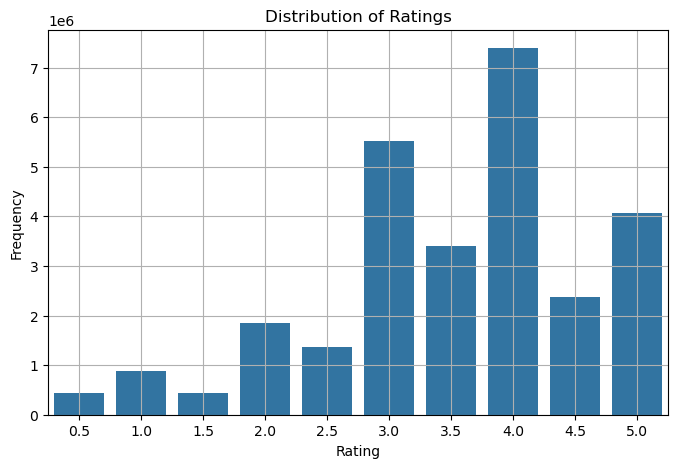

In [12]:
# Count the frequency of the ratings
rating_counts = df['rating'].value_counts().sort_index()
print(rating_counts)

# using bar chart to plot the distribution of the frequency of unique rating values
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## 1.5 - The probability density function
We write a function to plot the probability density based on `movieID` to show the realtionship between the number of movies with the number of rating given. With the second chart, we can see that there are some users giving majority of the rating, meanhwile the others (majority) giving a few. At this point, we can raise an assumption as the number of rating of the movies were not equally given across movies. In order to proving this point stronger, we will create a chart to answer the question as "How many users give 1 rating and who is the one contribute the highest number of ratings, regardless the rating value".

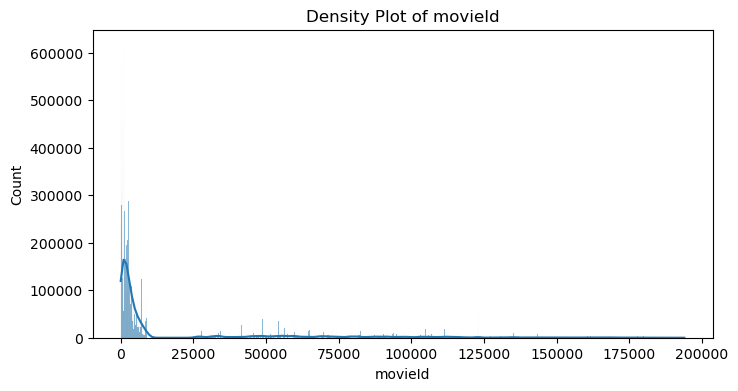

In [13]:
def plot_density(df, col):
    fig, ax = plt.subplots(figsize=(8,4))
    plot = sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Density Plot of {col}")

plot_density(df, "movieId")

## 1.6 - Number of Ratings given filtered by Users
As the relationship between number of ratings and number of users:
+ extreme right skewed (negative skewed) distribution: most of user give a few of ratings meanwhile the number of active rating users is minority represented by the peak is on the left of x-axes (small values) and long spread tail to the right
+ This extreme group gives more than 5000 ratings, contribute the most of the data

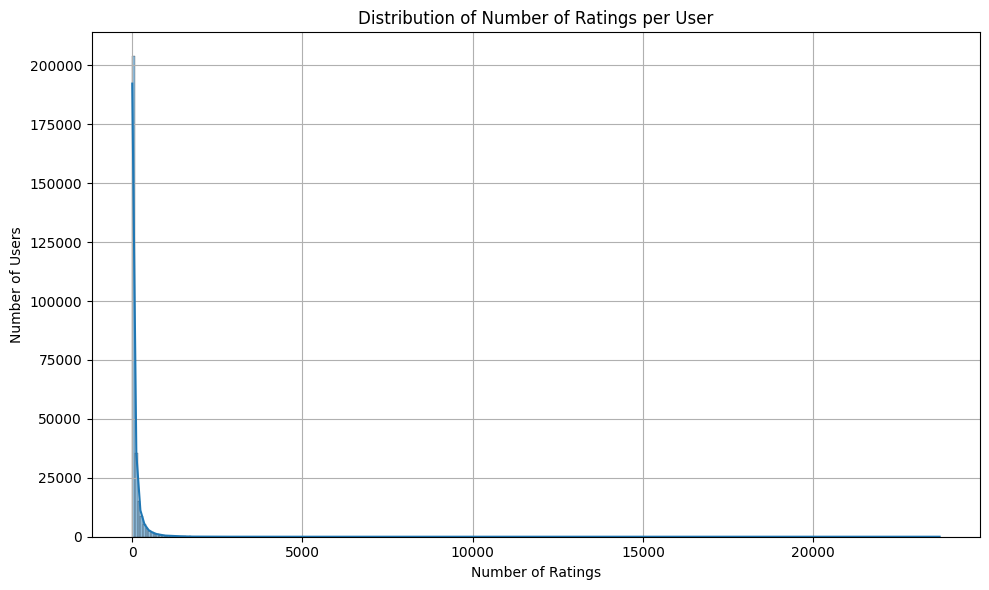

In [6]:
user_rating_counts = df.groupby('userId').size()

plt.figure(figsize=(10, 6))
sns.histplot(user_rating_counts, bins=300, kde=True)

plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')

plt.grid(True)
plt.tight_layout()
plt.show()

To strengthen our statement above, we add boxplot and calculated the summary stats as below

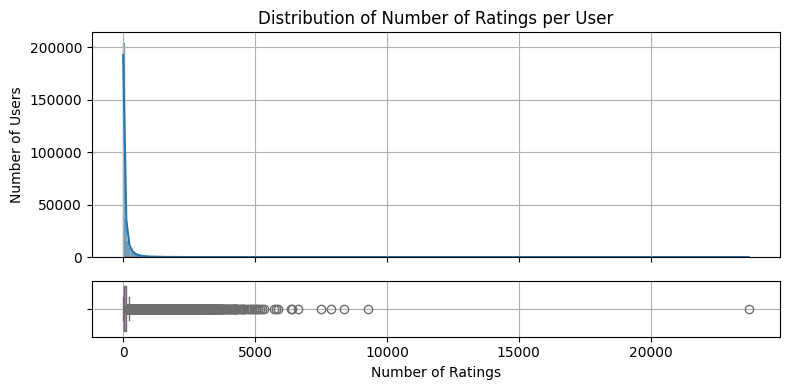

Minimum of rating count is 1
Maximum of rating count is 23715
Mean of rating count is 97
Q1 rating count is 15
Median rating count is 30
Q3 rating count is 95
80% of ratings is under 122
85% rating count is 165


In [7]:
fig, (axes1, axes2)  = plt.subplots(nrows=2, ncols=1, figsize=(8, 4), sharex = True, gridspec_kw={'height_ratios': [4, 1]})

# Histogram (top)
sns.histplot(user_rating_counts, bins=300, kde=True, ax=axes1)
axes1.set_title("Distribution of Number of Ratings per User")
axes1.set_xlabel("")
axes1.set_ylabel("Number of Users")
axes1.grid(True)

# Boxplot (bottom)
sns.boxplot(x=user_rating_counts, color='violet', ax=axes2)
axes2.set_xlabel("Number of Ratings")
axes2.grid(True)

plt.tight_layout()
plt.show()
print (f"Minimum of rating count is {int(user_rating_counts.min())}")
print (f"Maximum of rating count is {int(user_rating_counts.max())}")
print(f"Mean of rating count is {int(user_rating_counts.mean())}")
print(f"Q1 rating count is {int(user_rating_counts.quantile(0.25))}")
print(f"Median rating count is {int(user_rating_counts.median())}")
print(f"Q3 rating count is {int(user_rating_counts.quantile(0.75))}")
print(f"80% of ratings is under {int(user_rating_counts.quantile(0.8))}")
print(f"85% rating count is {int(user_rating_counts.quantile(0.85))}")


Beside the right skewness and the majority ratings contributed by the minority group (extreme active users), the boxplot along with statistics also tell additional insightful concluding:
+ Minimum = 1: at least one user rated once
+ Maximum = 23,715: at least one top super extreme active user contributed much more than the rest. This minority group can affect the result of the recommender system
+ Mean = 97: this statistic was influenced by the outliers since it was dragged to higher than Q3
+ The normal tendency of user was giving fewer than 95 ratings per users (Q3=95)

## 1.7 - Number of Ratings given filtered by Movies
In the case of Movies, we can observe the similar trend of the data distribution, as
+ Right skewed distribution, representing most of the movies were rated not too often
+ Median = 7 half movies receive fewer than 7 ratings
+ 75% of movies have fewer than 48 ratings.
+ Majority movies are in niche category or not really popular with mass audience
+ Meanwhile minority movie group show higher popularity as they received huge number of ratings

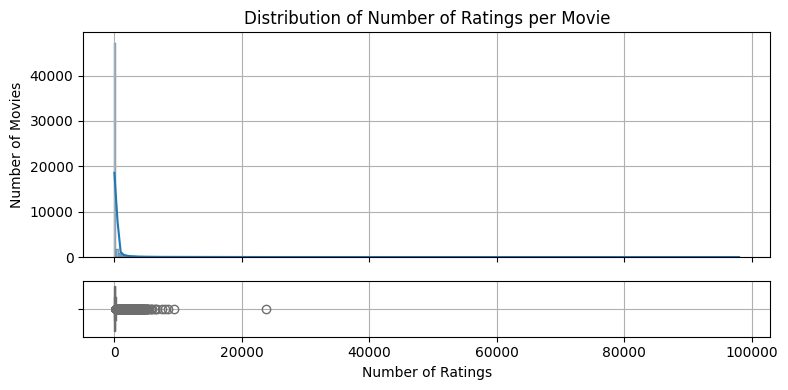

Minimum of rating count is 1
Maximum of rating count is 97999
Mean of rating count is 515
Q1 rating count is 2
Median rating count is 7
Q3 rating count is 48
80% of ratings is under 91
85% rating count is 205


In [8]:
movie_rating_counts = df.groupby('movieId').size()
fig, (axes1, axes2)  = plt.subplots(nrows=2, ncols=1, figsize=(8, 4), sharex = True, gridspec_kw={'height_ratios': [4, 1]})

# Histogram (top)
sns.histplot(movie_rating_counts, bins=300, kde=True, ax=axes1)
axes1.set_title("Distribution of Number of Ratings per Movie")
axes1.set_xlabel("")
axes1.set_ylabel("Number of Movies")
axes1.grid(True)

# Boxplot (bottom)
sns.boxplot(x=user_rating_counts, color='violet', ax=axes2)
axes2.set_xlabel("Number of Ratings")
axes2.grid(True)

plt.tight_layout()
plt.show()
print (f"Minimum of rating count is {int(movie_rating_counts.min())}")
print (f"Maximum of rating count is {int(movie_rating_counts.max())}")
print(f"Mean of rating count is {int(movie_rating_counts.mean())}")
print(f"Q1 rating count is {int(movie_rating_counts.quantile(0.25))}")
print(f"Median rating count is {int(movie_rating_counts.median())}")
print(f"Q3 rating count is {int(movie_rating_counts.quantile(0.75))}")
print(f"80% of ratings is under {int(movie_rating_counts.quantile(0.8))}")
print(f"85% rating count is {int(movie_rating_counts.quantile(0.85))}")

## 1.8 Conclusion
The distribution of ratings corresponding with movies or users are skewed to the right since the equal amount of ratings are not either given to movies or given by users. This is also a real case happen because of the differene in the popularity of the movies or in the opinion sharing tendency across users.
As a movie streaming platform, which method, item-based or user-based, should be used to build the recommender system? 

With the **User-based Collaborative Filtering**
+ strategy: recommend the movie list of existing users to similar new users targeted
+ majority of users give few ratings and minority dominates rating

With the **Item-based Collaborative Filtering**:
+ strategy: find and recommend similar items defined based on number of ratings
+ majority of ratings are placed for the hit movies.

As the number of users is much larger than the number of movies, so it will be more efficient to follow the Item-based. This is also a good initial strategy to subset the dataset due to the fact that a selected group of movies may represent the population but how much it could cover/ represent? Next step, we will calculate the relative frequency and cumulative coverage to evaluate this point. 

# 2 Data Subseting
This section presents how we could subset our data with the means of computing and running model more efficiently meanwhile keeping the original characteristics of the data

## 2.1 - Compute the relative frequency of top-k movies 
The plot below shows the relative frequency of ratings for the top-k movies, indicating what proportion of total ratings each movie accounts for. The area under the curve represents the cumulative coverage - showing how much of the total rating activity is captured by including the top k movies.

As we can see from the plot(and the figure shon previously), a relatively small subset of movies accounts for a large percentage of all ratings. This follows a long-tail distribution, where popular movies receive disproportionately more ratings than less popular ones.

This observation supports our subsetting strategy for two main reasons:
1. Computational efficiency - we can reduce the number of movies without losing the majority of our dataset 
2. Data quality - movies with more ratings have more reliable preference information to base recommendations on

By subsetting to include only the most frequently rated movies, we can build a more efficient recommender system while still preserving the core rating patterns in our dataset. 

2226


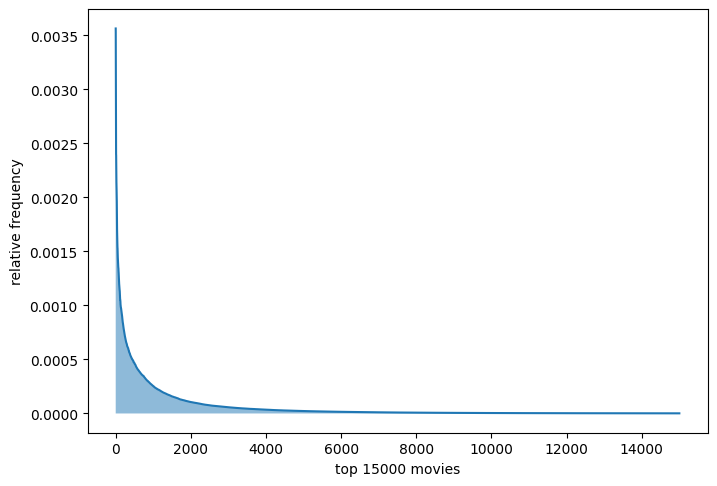

In [14]:
def plot_frequency(df, k):
    
    fig, ax = plt.subplots(figsize=(8,5.5))
    counts = df['movieId'].value_counts(sort=True, ascending=False)
    orig = counts.index.tolist()
    counts2 = counts.reset_index(inplace=False, drop=True)
    sub = counts2.index.tolist()

    relative_freq = counts / counts.sum() #showing how much/ how important single movie compare to the total (its frequency/ total occurence)
    cumulative_coverage = relative_freq.cumsum() 
    #the movies list is sorted descendingly,cummulative sum of relative frequency from top (most rated) to bottom (less rated)
    # showing how much of total rating in % could be explained by the top ranked movies
    k_80 = len(cumulative_coverage[cumulative_coverage <= 0.8])
    #at which index, the cumulative coverage is at most 80%
    print (k_80)
    
    sns.lineplot(x=counts2.index[0:k], y=counts2[0:k]/counts2[0:k].sum(), ax=ax)
    ax.fill_between(counts2.index[0:k], counts2[0:k]/counts2[0:k].sum(), alpha=0.5)
    ax.set_ylabel("relative frequency")
    ax.set_xlabel(f"top {k} movies")

plot_frequency(df, k=15000)

## 2.1 - Compute the relative frequency of top-k users

The plot below shows the relative frequency of ratings for the top-k users, indicating what proportion of total ratings each user accounts for. The area under the curve represents the cumulative coverage - showing how much of the total rating activity is captured by including the top k users.

As we can see from the plot, we observe that a similar effect to the top movies plot above- a smaller proportion of the users accounts form a big proportion of the ratings. However, the effect of top users is much less extreme compared to the top movies. 

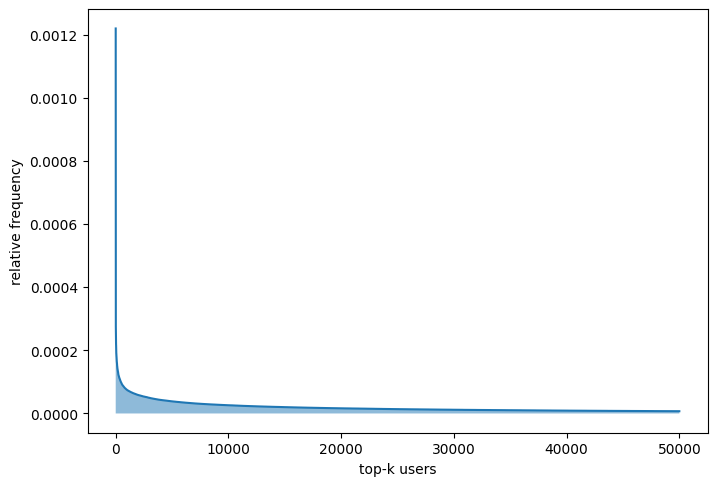

In [ ]:
def plot_frequency(df, k):
    
    fig, ax = plt.subplots(figsize=(8,5.5))
    counts = df['userId'].value_counts(sort=True, ascending=False)
    orig = counts.index.tolist()
    counts2 = counts.reset_index(inplace=False, drop=True)
    sub = counts2.index.tolist()

    sns.lineplot(x=counts2.index[0:k], y=counts2[0:k]/counts2[0:k].sum(), ax=ax)
    ax.fill_between(counts2.index[0:k], counts2[0:k]/counts2[0:k].sum(), alpha=0.5)
    ax.set_ylabel("relative frequency")
    ax.set_xlabel("top-k users")

plot_frequency(df, k=50000)

## 2.2 - Subset Selection for Top-k Movies and Users and update dataset

We extracted a subset of the dataset by selecting the top 4,000 movies and the top 40,000 users. These thresholds were determined based on the relative frequency graph, where we identified the smallest integer k such that the relative frequency approaches zero. The subset includes only the items that are present in both the top movies and top users, ensuring that the most relevant data is retained.

This approach significantly reduces the dataset size while preserving its core characteristics. However, even after this step, the dataset still contains over 15 million rows, which remains computationally intensive. To address this, further reduction of the dataset was necessary in subsequent steps.

In [2]:
def select_fixed_number(df, n_movies=4_000, n_users=40_000):
    filtered_movies = df[df['movieId'].isin(df['movieId'].value_counts().nlargest(n_movies).index)]
    filtered_users = df[df['userId'].isin(df['userId'].value_counts().nlargest(n_users).index)]
    return pd.merge(filtered_movies, filtered_users, how='inner')

df_selected = select_fixed_number(df)
df_selected.shape

(15525323, 4)

In [6]:
# Display the number of unique users and movies, and the shape of the dataframe
n_users = df_selected['userId'].nunique()
n_movies = df_selected['movieId'].nunique()

print(f"Number of unique users: {n_users}")
print(f"Number of unique movies: {n_movies}")
print(f"Shape of the dataframe: {df_selected.shape}")

Number of unique users: 40000
Number of unique movies: 4000
Shape of the dataframe: (15525323, 4)


In this subset we have 40000 unique users, 4000 unique moies and 15525323 observations

### 2.3.1 - Compare Rating distribution and Correlation

Check if the ratings distribution still looks similar to the original dataset. As the 2 charts below indicating the distribution of ratings in the original dataset and subsetting dataset, we can observe the pattern score distribution is similar to each other with the correlation is 99%

Rating Distribution Comparison:
        Original %  Selected %
rating                        
0.5       1.593993    1.487898
1.0       3.193236    3.068432
1.5       1.590267    1.737349
2.0       6.668099    7.023577
2.5       4.948643    5.691553
3.0      19.873815   19.714108
3.5      12.266442   13.947845
4.0      26.644297   26.705048
4.5       8.552272    8.628935
5.0      14.668936   11.995254


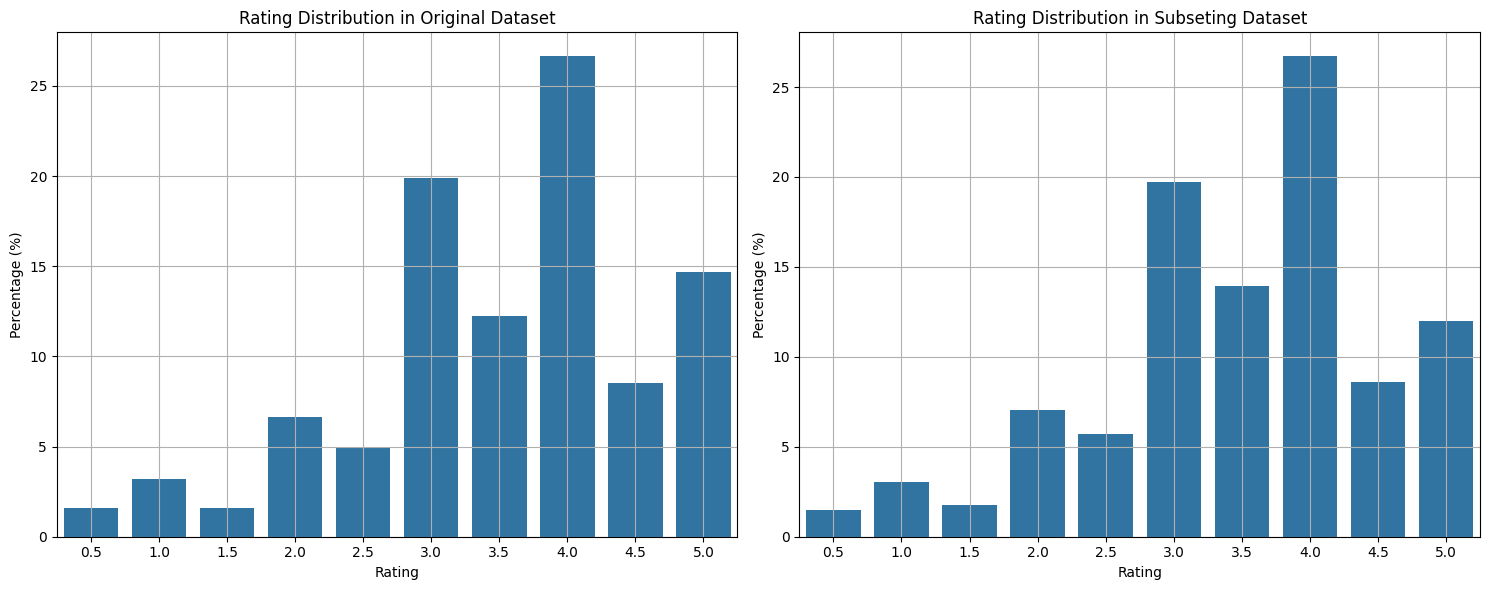


Correlation between distributions: 0.9914


In [7]:
# Calculate rating counts for original dataset and top-k dataset
rating_counts_original = df['rating'].value_counts().sort_index()
rating_counts_selected = df_selected['rating'].value_counts().sort_index()

# Calculate percentages
pct_original = rating_counts_original / rating_counts_original.sum() * 100
pct_selected = rating_counts_selected / rating_counts_selected.sum() * 100

# Create DataFrame for comparison
comparison_df = pd.DataFrame({
    'Original %': pct_original,
    'Selected %': pct_selected
})

# Print table
print("Rating Distribution Comparison:")
print(comparison_df)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original dataset
sns.barplot(x=pct_original.index, y=pct_original.values, ax=axes[0])
axes[0].set_title('Rating Distribution in Original Dataset')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Percentage (%)')
axes[0].grid(True)

# Top-k dataset
sns.barplot(x=pct_selected.index, y=pct_selected.values, ax=axes[1])
axes[1].set_title('Rating Distribution in Subseting Dataset')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Percentage (%)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Calculate correlation between the distributions
correlation = pct_original.corr(pct_selected)
print(f"\nCorrelation between distributions: {correlation:.4f}")


## 2.4 Take a stratified subset of the data 
However, more than 15 million instances are still a huge dataset. From the top movies and users, take 20% of the `df_selected` rows in such a way that the rating distribution is maintained 

In [16]:
from sklearn.model_selection import train_test_split as sklearn_train_test_split
from surprise import Dataset, Reader
# Initialize a dictionary to store model performance results
rmse_result_default = {}

# Stratified sample — preserve rating distribution in the reduced dataset
# Take 20% of the dataset in a stratified way
df_reduced, _ = sklearn_train_test_split(
    df_selected, 
    train_size=0.2, 
    stratify=df_selected['rating'], 
    random_state=42
)

print("unique users: " + str(len(df_reduced['userId'].unique())))
print("unique movies: " + str(len(df_reduced['movieId'].unique())))
print("Shape of reduced df:", df_reduced.shape)

# Convert df_reduced to Surprise Dataset for modeling
reader = Reader(rating_scale=(0.5, 5.0))
data_subset = Dataset.load_from_df(df_reduced[['userId', 'movieId', 'rating']], reader)


unique users: 40000
unique movies: 4000
Shape of reduced df: (3105064, 4)


After creating a stratified subset of the reduced dataset (`df_reduced`), we verified again if rating distribution remained consistent. Both the plots and the correlation analysis confirm that the `data_subset` retains a 99% equivalent rating distribution compared to the original dataset(`df`), indicating that the reduced subset is representitve of the original dataset.


Rating Distribution Comparison:
        Original %  Reduced %
rating                       
0.5       1.593993   1.487892
1.0       3.193236   3.068439
1.5       1.590267   1.737355
2.0       6.668099   7.023591
2.5       4.948643   5.691541
3.0      19.873815  19.714119
3.5      12.266442  13.947828
4.0      26.644297  26.705053
4.5       8.552272   8.628936
5.0      14.668936  11.995244


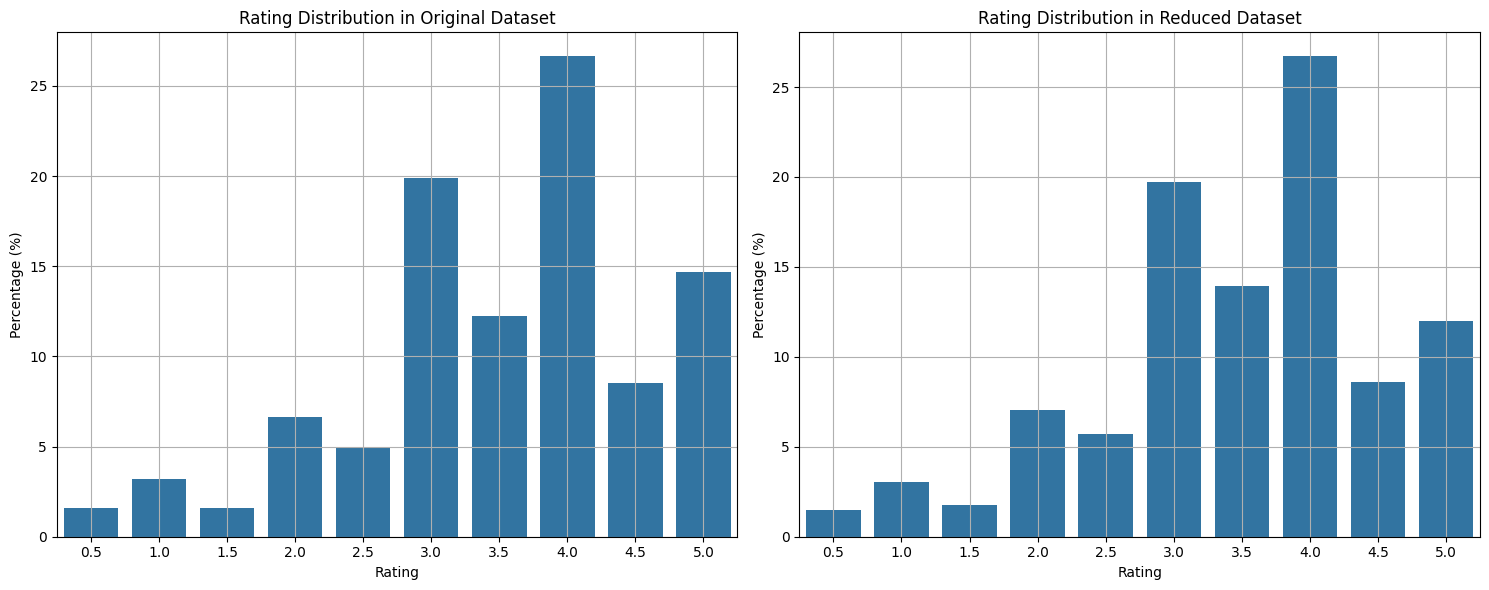


Correlation between distributions: 0.9914


In [52]:
# Calculate rating counts for original dataset and df_reduced dataset
rating_counts_original = df['rating'].value_counts().sort_index()

# Convert data_subset back to a pandas DataFrame
data_subset_df = pd.DataFrame(data_subset.raw_ratings, columns=['userId', 'movieId', 'rating', 'timestamp'])
rating_counts_subset = data_subset_df['rating'].value_counts().sort_index()
# Ensure userId and movieId columns are of the same type as in the original dataset
data_subset_df['userId'] = data_subset_df['userId'].astype(int)
data_subset_df['movieId'] = data_subset_df['movieId'].astype(int)
# Calculate percentages
pct_original = rating_counts_original / rating_counts_original.sum() * 100
pct_reduced = rating_counts_subset / rating_counts_subset.sum() * 100

# Create DataFrame for comparison
comparison_df = pd.DataFrame({
    'Original %': pct_original,
    'Reduced %': pct_reduced
})

# Print table
print("Rating Distribution Comparison:")
print(comparison_df)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original dataset
sns.barplot(x=pct_original.index, y=pct_original.values, ax=axes[0])
axes[0].set_title('Rating Distribution in Original Dataset')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Percentage (%)')
axes[0].grid(True)

# Top-k dataset
sns.barplot(x=pct_reduced.index, y=pct_reduced.values, ax=axes[1])
axes[1].set_title('Rating Distribution in Reduced Dataset')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Percentage (%)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Calculate correlation between the distributions
correlation = pct_original.corr(pct_reduced)
print(f"\nCorrelation between distributions: {correlation:.4f}")

## 2.5 Conclusion data subsetting 
By first creating a subset of the dataset containing the top-K items and users, we reduced the dataset to 15 million rows. From this subset, we then applied stratified sampling to ensure the rating distribution was preserved, resulting in a final dataset of 3.1 million observations. This final dataset will be used to train and evaluate our models.

# Part 3 – Configure the models 

This section presents the configuration of selected models as `KNN` and `SVD` with the performance evaluation comparision with baseline model as `NormalPredictor`

In [40]:
# Import essential libraries
from surprise.model_selection.split import KFold
from surprise import NormalPredictor
from surprise.model_selection import cross_validate
from surprise import KNNBaseline
import numpy as np
from surprise import SVD

## 3.1 - Configure the NormalPredictor model as baseline model
`NormalPredictor` is the random predictor model predicting the rating by ignoring users and items and just randomly sampling from the normal distribution of ratings in the training set. The result gave an average RMSE of 1.4251

In [17]:
# cross validation K-fold with 5 splits and measure the RMSE of the test set
cv = KFold(n_splits=5, random_state=42, shuffle=True)
cv_normal = cross_validate(NormalPredictor(), data_subset, cv=cv, return_train_measures=True)
# Print cross-validation results
print("Cross-validation results for Normal Predictor:")
print(cv_normal)

# Calculate and display averaged RMSE test score
averaged_rmse_test_normal = cv_normal["test_rmse"].mean()
print(f"\nAverage RMSE on test set: {averaged_rmse_test_normal:.4f}") 

Cross-validation results for Normal Predictor:
{'test_rmse': array([1.42523316, 1.42425919, 1.42585779, 1.42408786, 1.42597168]), 'train_rmse': array([1.42619735, 1.42543324, 1.42580223, 1.42445807, 1.42517542]), 'test_mae': array([1.13635066, 1.13545975, 1.13666432, 1.13531811, 1.13711333]), 'train_mae': array([1.13714895, 1.13633514, 1.13668541, 1.13522018, 1.13597409]), 'fit_time': (3.1898767948150635, 3.803766965866089, 3.9503023624420166, 4.0787131786346436, 3.7361032962799072), 'test_time': (1.8061511516571045, 2.2026617527008057, 3.120145320892334, 2.4028048515319824, 1.6591064929962158)}

Average RMSE on test set: 1.4251


## 3.2 - Configure KNNBaseline

The selected method is based on the KNNBaseline algorithm, a collaborative filtering approach leveraging nearest neighbor methodologies enhanced with baseline estimates. This algorithm operates by identifying a predefined number of most similar items or users—commonly referred to as neighbors—and uses their historical rating patterns to predict ratings for unseen items. The similarity among neighbors can be calculated using various similarity metrics.In our project, the hyperparameters to be optimized are the number of neighbors (`k`) and the similarity configuration options ('sim_options'). These hyperparameters are explained below:

* **Number of neighbors (`k`)**: This parameter determines how many of the nearest neighbors are taken into account when aggregating ratings. If `k` is set too low, the algorithm might fail to capture enough collaborative signals, resulting in high-variance predictions that are overly dependent on a few data points. On the other hand, a very high value of `k` may incorporate too many weakly related neighbors, which can dilute the quality of the recommendation and reduce accuracy. Optimizing `k` helps balance this trade-off between bias and variance. 

* **Minimum number of neighbors (`min_k`)**: This parameter specifies the minimum number of neighbors required to perform the aggregation for a prediction. If the actual number of neighbors falls below this threshold, the algorithm will revert to a baseline estimate instead of relying on sparse and potentially unreliable data. Lower values of `min_k` increase coverage but risk poor prediction quality, while higher values improve trustworthiness at the cost of skipping some predictions.

* **Similarity metric (`name`)**: This setting defines the mathematical function used to compute similarity between users or items. 

  * **Cosine similarity('cosine')** captures the angle between rating vectors, making it effective for sparse datasets.
  * **Pearson baseline similarity** adjusts for global rating biases, offering refined similarity measures in scenarios with strong user or item preferences.
  * **Mean squared difference (MSD)** computes rating dissimilarity through squared differences, offering a simple and efficient alternative.
  
* **Shrinkage (`shrinkage`)**: Used exclusively with Pearson baseline similarity, this parameter acts as a regularizer that moderates high similarity values caused by low co-occurrence counts(only a few ratings available). By increasing shrinkage, we pull similarity estimates closer to a neutral baseline, improving their stability especially in sparse rating regions(movies that have fewer ratings).

* **User-based (`user_based`)**: This boolean flag determines whether similarities are computed between users (user-based) or between items (item-based). While user-based filtering can be intuitive and effective in certain contexts, it tends to be memory-intensive and computationally expensive on large datasets. In our project, we use item-based similarity (`user_based=False`) to ensure scalability and avoid memory issues.

* **Minimum support (`min_support`)**: This parameter sets a threshold for the number of common ratings required to compute a non-zero similarity score between two users or items. As we've set our `user_based` to `False` it will be between items. Lower values may yield noisy or spurious similarities, while higher values restrict the similarity computation to stronger, more reliable overlaps. Lowering this value helps in sparser dataset, such as MovieLens where overlap between user ratings or item ratings is limited.

<div class="alert alert-info">Use the default parameters for KNNBaseline and SVD and 5-fold cross-validation  </div>

When we set the default parameters, KNNBaseline runs into error due to the huge memory usage of storing the matrix. Therefore, 
`sim_options = {'user_based': False}` (item-based filtering) to avoid memory issues.

In [48]:
# Create KNNBaseline model with default setting
sim_options = { 
    'user_based': False,  # Use item-based approach to reduce memory usage
}
# Use default KNNBaseline model
cv_knn = cross_validate(KNNBaseline(sim_options=sim_options),
                        data_subset, cv=cv,  n_jobs=-1)
averaged_rmse_test = cv_knn["test_rmse"].mean()
print(f"\nAverage RMSE on test set: {averaged_rmse_test:.4f}")

rmse_result_default = {}
rmse_result_default['KNNBaseline'] = averaged_rmse_test


Average RMSE on test set: 0.8300


### 3.3 Configure SVD 

The selected method is based on the Singular Value Decomposition (SVD) algorithm, a matrix factorization approach widely used in collaborative filtering for recommender systems. SVD decomposes the user-item interaction matrix into the product of lower-dimensional matrices that capture latent features of users and items. These latent representations are then used to predict unknown ratings by modeling the interactions in this reduced feature space.

The SVD method involves several important hyperparameters that influence its learning dynamics and generalization capabilities. In our project, the hyperparameters to be optimized are the number of latent factors (`n_factors`), the number of training iterations (`n_epochs`), the learning rate (`lr_all`), and the regularization strength (`reg_all`). These hyperparameters are explained below:

- **Number of latent factors (`n_factors`)**: This parameter determines the dimensionality of the latent feature space in which users and items are embedded. A small number of factors may lead to underfitting, failing to capture the complexity of user preferences and item attributes. Conversely, a very high number of factors increases model complexity and the risk of overfitting. 

- **Number of epochs (`n_epochs`)**: This denotes how many full passes the model makes over the entire training dataset. Fewer epochs may result in underfitting, where the model fails to learn meaningful patterns. Too many epochs can lead to overfitting, especially if the model starts to memorize noise in the training data. 

- **Learning rate (`lr_all`)**: This controls the step size taken during the gradient descent updates. A higher learning rate allows faster convergence but can cause instability or overshooting optimal values. A smaller learning rate provides more stable convergence but if it is too small it will take too long to converge. 

- **Regularization strength (`reg_all`)**: This parameter penalizes the magnitude of learned weights to prevent overfitting. A low regularization strength might allow the model to fit noise in the data, while too much regularization can overly constrain the model, limiting its ability to capture patterns. Tuning regularization helps maintain a balance between model complexity and robustness.


In [49]:
# Create SVD model with default setting
from surprise import SVD
cv_svd = cross_validate(SVD(random_state=42, verbose= True), data_subset, cv=cv, n_jobs=-1)
averaged_rmse_test = cv_svd["test_rmse"].mean()
print(f"\nAverage RMSE on test set: {averaged_rmse_test:.4f}")

rmse_result_default['SVD'] = averaged_rmse_test


Average RMSE on test set: 0.8378


Default settings performance comparison

1. **NormalPredictor**:
    - The baseline model, `NormalPredictor`, achieved the highest RMSE of **1.4251**. This is expected as it predicts ratings randomly based on the normal distribution of ratings in the training set, without considering user or item-specific patterns.

2. **KNNBaseline**:
    - The `KNNBaseline` model, using default settings, achieved an average RMSE of **0.8300**.

3. **SVD**:
    - The `SVD` model, with default settings, achieved an average RMSE of **0.8378**. 

<div class="alert alert-info">Parameters manually setting and adjustment  </div>

So KNNBaseline and SVD clearly out-perform NormalPredictor. At this point, we will try to improve the results of these algorithms. To do that, perform 5-fold cross-validation on the setting and making adjustments manually on different parameters: 

+ `k`, `min_k` values and `sim_options` for KNN
+  `n_factors`, `n_eposch`, `lr_all`, and `ref_all` for SVD

In [47]:
# 1st adjustment
sim_options_1 = {"name": "cosine","user_based": False}
cv_knn_1 = cross_validate(KNNBaseline(k=30, min_k=1,verbose=False, sim_options=sim_options_1), 
                          data_subset, cv=cv, return_train_measures=True)

cv_svd_1 = cross_validate(SVD(n_factors=100, n_epochs=30, lr_all=0.01, reg_all=0.01,
                              random_state=42, verbose= True), 
                          data_subset, cv=cv, return_train_measures=True, n_jobs=-1)

# Show results
rmse_result_adjust_1 = {}
rmse_result_adjust_1 ["KNNBaseline"] = cv_knn_1["test_rmse"]
rmse_result_adjust_1 ["SVD"] = cv_svd_1["test_rmse"]
rmse_result_adjust_1

{'KNNBaseline': array([0.83739163, 0.83814942, 0.83831418, 0.83666341, 0.83730188]),
 'SVD': array([0.91811366, 0.91691906, 0.91698642, 0.91677564, 0.91769484])}

In [50]:
# 2nd adjustment
sim_options_2 = {"name": "pearson_baseline","user_based": False}
cv_knn_2 = cross_validate(KNNBaseline(k=30, min_k=3,verbose=False, sim_options=sim_options_1), 
                          data_subset, cv=cv, return_train_measures=True)

cv_svd_2 = cross_validate(SVD(n_factors=50, n_epochs=20, lr_all=0.01, reg_all=0.01,
                              random_state=42, verbose= True), 
                          data_subset, cv=cv, return_train_measures=True, n_jobs=-1)

# Show results
rmse_result_adjust_2 = {}
rmse_result_adjust_2 ["KNNBaseline"] = cv_knn_2["test_rmse"]
rmse_result_adjust_2 ["SVD"] = cv_svd_2["test_rmse"]
rmse_result_adjust_2

{'KNNBaseline': array([0.8373917 , 0.83814942, 0.83831418, 0.8366644 , 0.83730188]),
 'SVD': array([0.88539629, 0.88404743, 0.88526643, 0.88477531, 0.88378782])}

In [53]:
print ("Default setting parameter")
print('Average RMSE KNNBaseline:', round(np.mean(rmse_result_default ["KNNBaseline"]), 4))
print('Average RMSE SVD:', round(np.mean(rmse_result_default ["SVD"]), 4))

print ("\nResult after 1st adjustment on parameters")
print('Average RMSE KNNBaseline:', round(np.mean(rmse_result_adjust_1 ["KNNBaseline"]), 4))
print('Average RMSE SVD:', round(np.mean(rmse_result_adjust_1 ["SVD"]), 4))

print ("\nResult after 2nd adjustment on parameters")
print('Average RMSE KNNBaseline:', round(np.mean(rmse_result_adjust_2 ["KNNBaseline"]), 4))
print('Average RMSE SVD:', round(np.mean(rmse_result_adjust_2 ["SVD"]), 4))

Default setting parameter
Average RMSE KNNBaseline: 0.83
Average RMSE SVD: 0.8378

Result after 1st adjustment on parameters
Average RMSE KNNBaseline: 0.8376
Average RMSE SVD: 0.9173

Result after 2nd adjustment on parameters
Average RMSE KNNBaseline: 0.8376
Average RMSE SVD: 0.8847


After results above, we can clearly see that when setting and adjusting parameter, the performance of the models are changed, either better or worse. Therefore, it is wise to try tuning parameters in order to find the customized optimal parameter combinations which could actually improve the performance of the model automatically, rather than manually test-error iterations.

# 4 Hyperparameter-tuning

These parameters are systematically explored using `GridSearchCV` and `RandomizedSearchCV` to identify the combination that minimizes the RMSE (Root Mean Squared Error) on the test set. Initially, `RandomizedSearchCV` is employed to efficiently explore a broad range of hyperparameters. Subsequently, `GridSearchCV` is used to refine the search around the most promising configurations. 

## 4.1 Hyperparameter-tuning for KNNBaseline


We have to write class to pre-define the sim_options for KNNBaseline, by which `user_based = False` will be set as default. The intention of this additional task is to prevent the memory error to happen.



In [ ]:
from surprise.model_selection import GridSearchCV
from surprise.model_selection import RandomizedSearchCV

cv = KFold(n_splits=5, random_state=42, shuffle=True)

# Define parameters for grid search
param_grid_default = {}
rmse_result_default = {"NormalPredictor": cv_normal["test_rmse"]}

# Define parameter grid for KNNBaseline
# For RandomizedSearchCV, we need to specify the parameters differently
param_grid = {
    'k': [20, 40, 60, 80],
    'min_k': [3, 5, 10],
    'sim_options': {
        'name': ['cosine', 'pearson_baseline', 'msd'],
        'user_based': [False],  # Always False to avoid memory issues
        'min_support': [2, 5],
        'shrinkage': [50, 100, 150,]  # Only used with pearson_baseline
    }
}

# Use RandomizedSearchCV to more efficiently explore the parameter space
random_search = RandomizedSearchCV(
    KNNBaseline, 
    param_distributions=param_grid, 
    n_iter=100,  
    measures=['rmse'], 
    cv=cv, 
    n_jobs=-1, 
    random_state=42
)

# Fit the random search
random_search.fit(data_subset)

# Best parameters and score
print(f"Best parameters: {random_search.best_params['rmse']}")
print(f"Best RMSE: {random_search.best_score['rmse']:.4f}")

# Store results for comparison
best_knn_params = random_search.best_params['rmse']
best_knn_score = random_search.best_score['rmse']

Best parameters: {'k': 40, 'min_k': 5, 'sim_options': {'name': 'pearson_baseline', 'user_based': False, 'min_support': 5, 'shrinkage': 150}}
Best RMSE: 0.8144


In [26]:
# Extract the best parameters from refined grid search
best_k = best_knn_params['k']
best_min_k = best_knn_params['min_k']
best_min_support = best_knn_params['sim_options']['min_support']
best_shrinkage = best_knn_params['sim_options']['shrinkage']


final_param_grid = {
    'k': [best_k-2, best_k, best_k+2],
    'min_k': [best_min_k-1, best_min_k, best_min_k+1],
    'sim_options': {
        'name': ['pearson_baseline'],
        'user_based': [False],
        'min_support': [best_min_support],
        'shrinkage': [best_shrinkage-10, best_shrinkage, best_shrinkage+10]
    }
}

final_grid_search = GridSearchCV(KNNBaseline, final_param_grid, measures=['rmse'], cv=cv, n_jobs=-1)
final_grid_search.fit(data_subset)

# Store results for comparison
best_final_params = final_grid_search.best_params['rmse']
best_final_score = final_grid_search.best_score['rmse']

print(f"Final best parameters: {best_final_params}")
print(f"Final best RMSE: {best_final_score:.4f}")


Final best parameters: {'k': 38, 'min_k': 6, 'sim_options': {'name': 'pearson_baseline', 'user_based': False, 'min_support': 5, 'shrinkage': 160}}
Final best RMSE: 0.8143


 **KNNBaseline**:

- The best parameters identified for the KNNBaseline model were:
  ```python
  {'k': 38, 'min_k': 6, 'sim_options': {'name': 'pearson_baseline', 'user_based': False, 'min_support': 5, 'shrinkage': 160}}
  ```
- This configuration achieved an RMSE of **0.8143**, which is an improvement over the default settings and manual parameter adjustments. 

## 4.2 Hyper-parameter for SVD

In [28]:
from surprise.model_selection import RandomizedSearchCV

# Define a more comprehensive parameter grid for SVD
param_grid_SVD_random = {
    'n_factors': [30, 50, 100, 150, 200], 
    'n_epochs': [20, 30, 40, 50],
    'lr_all': [0.005, 0.007, 0.01, 0.02, 0.05],
    'reg_all': [0.02, 0.05, 0.1, 0.2]
}

# Set up RandomizedSearchCV for more efficient exploration
random_search_SVD = RandomizedSearchCV(
    SVD, 
    param_distributions=param_grid_SVD_random, 
    n_iter=100,  
    measures=['rmse'], 
    cv=cv, 
    n_jobs=-1,  
    joblib_verbose=3
)

# Fit the random search
random_search_SVD.fit(data_subset)

# Best parameters and score
print(f"Best SVD parameters from random search: {random_search_SVD.best_params['rmse']}")
print(f"Best RMSE from random search: {random_search_SVD.best_score['rmse']:.4f}")

# Store results for comparison
best_svd_params = random_search_SVD.best_params['rmse']
best_svd_score = random_search_SVD.best_score['rmse']



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed: 26.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 50.5min finished


Best SVD parameters from random search: {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.02, 'reg_all': 0.1}
Best RMSE from random search: 0.8069


In [29]:

# Extract best values from first search
best_n_factors = best_svd_params['n_factors']
best_n_epochs = best_svd_params['n_epochs']
best_lr = best_svd_params['lr_all']
best_reg = best_svd_params['reg_all']

# Define refined parameter grid focused around best values
refined_param_grid_SVD = {
    'n_factors': [max(best_n_factors-10, 10), best_n_factors, min(best_n_factors+10, 200)],
    'n_epochs': [max(best_n_epochs-5, 10), best_n_epochs, min(best_n_epochs+5, 60)],
    'lr_all': [max(best_lr*0.8, 0.0005), best_lr, min(best_lr*1.2, 0.02)],
    'reg_all': [max(best_reg*0.8, 0.01), best_reg, min(best_reg*1.2, 0.4)]
}

# More focused grid search around best parameters
refined_grid_search_SVD = GridSearchCV(
    SVD, refined_param_grid_SVD, measures=['rmse'], cv=cv, n_jobs=-1, joblib_verbose=2
)

# Fit the refined search
refined_grid_search_SVD.fit(data_subset)

# Best parameters and score from refined search
print(f"\nRefined search best SVD parameters: {refined_grid_search_SVD.best_params['rmse']}")
print(f"Refined search best RMSE: {refined_grid_search_SVD.best_score['rmse']:.4f}")

# Final best parameters for SVD
final_best_svd_params = refined_grid_search_SVD.best_params['rmse']
final_best_svd_score = refined_grid_search_SVD.best_score['rmse']

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed: 20.8min
[Parallel(n_jobs=-1)]: Done 333 tasks      | elapsed: 54.2min



Refined search best SVD parameters: {'n_factors': 160, 'n_epochs': 55, 'lr_all': 0.016, 'reg_all': 0.08000000000000002}
Refined search best RMSE: 0.8031


[Parallel(n_jobs=-1)]: Done 405 out of 405 | elapsed: 65.8min finished


**SVD**:  
    - The best parameters identified for the SVD model were:  
      ```python
      {'n_factors': 160, 'n_epochs': 55, 'lr_all': 0.016, 'reg_all': 0.08}
      ```  
    - This configuration achieved an RMSE of **0.8031**, which is an improvement over the default settings and manual parameter adjustments.   

# 5. Evaluation on best parameter settings

## 5.1 KNNBaseline
The optimized KNNBaseline model, of which parameter setting as `{'k': 38, 'min_k': 6, 'name': 'pearson_baseline', 'user_based': False, 'min_support': 5, 'shrinkage' 160}` achieved RMSE of 0.8143. If we do a different seed initialization for the K-Fold cross-validation, we aim to ensure that the model's performance is not overly dependent on a specific data split. By changing the random seed, we generate different train-test splits, which helps us evaluate the robustness and generalization capability of the model. 

In [32]:
import numpy as np

# Fitting the best KNN model with optimal parameters from grid search
best_KNN = KNNBaseline(
    k=38, 
    min_k=6, 
    sim_options={
        "name": "pearson_baseline",
        "user_based": False,
        "min_support": 5,
        "shrinkage": 160
    }, 
    verbose=False,
    n_jobs=-1
)

# Cross-validate to check performance
knn_results = cross_validate(best_KNN, data_subset, cv=cv, return_train_measures=True)
print("Cross-validation results for best KNN model:")
print(f"Average test RMSE: {np.mean(knn_results['test_rmse']):.4f}")



Cross-validation results for best KNN model:
Average test RMSE: 0.8143


Different seed initialization(random_state = 101) for the cross-validation showed a RMSE of 0.8142, very similar to the first result which had random_state = 42. This consistency demonstrates the robustness of the found hyperparameters to prdocue a KNNBaseline model that consistently performs well across different data splits.

In [34]:
# Set a new random seed for cross-validation
cv_new_seed = KFold(n_splits=5, random_state=101, shuffle=True)

# Cross-validate the KNNBaseline model with the new random seed
knn_results_new_seed = cross_validate(best_KNN, data_subset, cv=cv_new_seed)

# Print the results
print("Cross-validation results for best KNN model with random_state=101:")
print(f"Average test RMSE: {np.mean(knn_results_new_seed['test_rmse']):.4f}")

Cross-validation results for best KNN model with random_state=101:
Average test RMSE: 0.8142


## 5.1 SVD
The optimized SVD model with`{'n_factors': 160, 'n_epochs': 55, 'lr_all': 0.016, 'reg_all': 0.08}` achieved RMSE of 0.8032. 

In [38]:
# Use the optimal parameters found during grid search for SVD
best_SVD = SVD(
    n_factors=160, 
    n_epochs=55, 
    lr_all=0.016, 
    reg_all=0.08, 
    random_state=42,  
    verbose=False
)

# Cross-validate to check performance
svd_results_final = cross_validate(best_SVD, data_subset, cv=cv)

# Print results
print("Cross-validation results for best SVD model with random_state=42:")
print(f"Average test RMSE: {np.mean(svd_results_final['test_rmse']):.4f}")

Cross-validation results for best SVD model with random_state=42:
Average test RMSE: 0.8032


When using a different seed initialization for cross-validation (`random_state=101`) and the SVD model itself (`random_state=101`), the RMSE achieved is 0.8034, which is only a 0.0002 difference compared to the RMSE obtained with `random_state=42`. This minimal variation demonstrates the strong generalization capability and robustness of the found hyperparameters to produce an SVD model performs well across different data splits.

In [39]:
# Use a different random seed (101)
best_SVD = SVD(
    n_factors=160, 
    n_epochs=55, 
    lr_all=0.016, 
    reg_all=0.08, 
    random_state=101,  
    verbose=False
)

# Cross-validate to check performance
svd_results_final = cross_validate(best_SVD, data_subset, cv=cv_new_seed)

# Print results
print("Cross-validation results for best SVD model with random_state=101:")
print(f"Average test RMSE: {np.mean(svd_results_final['test_rmse']):.4f}")

Cross-validation results for best SVD model with random_state=101:
Average test RMSE: 0.8034


## Evaluation of Results

### Model Performance Comparison
The performance of the models was evaluated using RMSE (Root Mean Squared Error) as the metric. Below is a summary of the results:

| Model                  | Default RMSE | Optimized RMSE | Improvement |
|------------------------|--------------|----------------|-------------|
| **NormalPredictor**    | 1.4251       | N/A            | N/A         |
| **KNNBaseline**        | 0.8300       | 0.8143         | 1.89%       |
| **SVD**                | 0.8378       | 0.8032         | 4.13%       |


### Baseline Performance

NormalPredictor, which generates predictions based on the rating distribution of the training set (which is assumed to be normal), performed predictably poorly with an RMSE of 1.4251. Both KNNBaseline and SVD significantly outperformed the baseline, even before any hyperparameter tuning.

### KNNBaseline

The KNNBaseline model demonstrated a default RMSE of 0.8300, which is a lot lower than that of the baseline. After tuning hyperparameters, the optimized version achieved an RMSE of 0.8143, representing a 1.89% improvement.

One of KNNBaseline's key strengths lies in its interpretability. It allows us to trace how recommendations are generated via neighborhood similarities, which is valuable in settings where explainability is important. However, it is also computationally expensive on large datasets. KNN requires memory and storage since it does not generalize from the training data but instead relies on retaining the entire dataset for comparison. This can lead to substantial costs in memory and processing time, which are further amplified as the dataset grows [3][4].

In our case, this limitation became apparent when we attempted to use user-based similarity (i.e., setting user_based=True) with the MovieLens dataset. Because the dataset includes significantly more users than movies, the memory usage exceeded available resources, causing the process to crash. As a result, we decided to switch to item-based similarity (i.e., computing similarities between movies) to successfully build the model.

These challenges suggest that while KNN-based methods like KNNBaseline are valuable for smaller or moderately sized datasets, they may become impractical with larger datasets.


### SVD

The SVD (Singular Value Decomposition) model yielded slightly higher default RMSE (0.8378) than KNNBaseline. However, after hyperparameter tuning, it outperformed all models with an RMSE of 0.8032.

SVD is a matrix factorization method that decomposes the user-item interaction matrix into three smaller matrices: the user-feature matrix, the diagonal matrix of singular values, and the item-feature matrix. This decomposition is designed to capture the underlying structure of the data by identifying latent factors that influence user-item interactions. SVD transforms high-dimensional, sparse data into a lower-dimensional representation, making it possible to approximate the original matrix with far fewer dimensions. This process reveals patterns that are not immediately apparent, such as a user's preference for a genre or a movie's appeal to a specific audience segment.

This capability allows SVD to generalize effectively to unseen data, making it particularly powerful for sparse datasets like MovieLens, where many ratings are missing. Unlike neighborhood-based methods such as KNN, SVD does not rely on direct similarity but rather learns complex patterns that drive user preferences. It achieves this with better scalability since the model learns compact latent representations rather than storing and comparing all pairwise interactions.

However, SVD also introduces limitations. One of the most significant is its lack of interpretability—latent factors are mathematically derived from the original features and lack interpretability. 

Compared to KNNBaseline, SVD provides superior accuracy and better handling of high-dimensional data at the cost of transparency and computational simplicity. While KNNBaseline may be favored for smaller datasets or applications requiring explainability, SVD is better suited to large-scale systems that demand high accuracy and robustness[1][2].

## Discussion

While both KNNBaseline and SVD models already demonstrate considerable improvements over the baseline, there remains potential for further enhancement.

In the case of KNNBaseline, we encountered notable challenges related to scalability. Specifically, enabling user-based similarity (i.e., user_based=True) was infeasible due to substantial memory constraints caused by the high number of users in the dataset. This limitation forced us to switch to item-based similarity. Future improvements could focus on strategies to mitigate these resource limitations, such as exploring more memory-efficient data structures like Ball Trees or implementing user filtering techniques to reduce the dimensionality of the similarity space. 

In the case of SVD, performance could be further refined by expanding the hyperparameter search space. However, this process can be time-consuming and computationally expensive when using traditional grid or random search methods provided by the SurPRISE library. To address this, more sophisticated optimization techniques such as Optuna may offer a solution. By exploring the most promising regions of the search space, Optuna can achieve better model performance with fewer trials.  Additionally, extending the SVD approach to SVD++—which includes implicit feedback—could significantly improve recommendations by accounting for user interactions beyond explicit ratings.

Lastly, using external content features (e.g., movie genres, tags) in combination with collaborative data might lead to better personalization. These content features can be merged with the collaborative filtering data during preprocessing. 

## Conclusion

The comparative analysis highlights that while both KNNBaseline and SVD are superior to the baseline predictor, their use cases differ:

KNNBaseline is recommended when explainability and efficiency are prioritized, especially for smaller datasets.

SVD is preferred when accuracy and scalability are the main objectives. This particularly usefull for larger datasets.

### References:

GeeksforGeeks. "Singular Value Decomposition (SVD)." Available at: https://www.geeksforgeeks.org/singular-value-decomposition-svd/

Gundersen, G. (2018). "Singular Value Decomposition (SVD)." Available at: https://gregorygundersen.com/blog/2018/12/10/svd/

Toji. (2018). "Why KNN Doesn’t Scale." Available at: https://dev.to/toji/why-knn-doesnt-scale-3461

IBM. "KNN Overview." Available at: https://www.ibm.com/think/topics/knn

